In [2]:
import os 
from pathlib import Path


import numpy as np
import pandas as pd
import ast
from typing import Dict, Any

# data loader
# from reports_scripts import parse_folder

# seting global dir
cwd=Path.cwd()
if cwd.parent.name == "resources":
    # os.chdir(cwd.parent.parent) 
    os.chdir(cwd.parent.parent) 
os.getcwd()


'/home/maxi7524/repositories/final'

In [3]:
from PromotorOptimizer.loaders import OptimizerLoader

data_path =  Path("data") / "results_final_cross_validated"
df = OptimizerLoader(data_path)

In [4]:
df.columns

Index(['sequence_name', 'interpreter', 'optimizer', 'iteration',
       'hamming_trajectory', 'shannon_entropy'],
      dtype='str')

#TODO w górę do loaderów oddelegoą
c 

In [8]:
df

,file_id,sequence_name,interpreter,optimizer,job_type,model_type,iteration,ensemble_score,gc_content,temperature,current_sequence,current_beam_population,interpreter_weights,score_Deepstar,score_Second_Deepstarr,score_Model_Original,variance_individual,weight_individual,variance_aggregated,weight_aggregated
0,results_optimization_final_beam.json,seq_4_no_active,InSilicoMutagenesis,BeamSearchOptimizer,optimization,final_beam,0,-0.119823,0.439130,0.000000,TCGGTTCACGCAATGTGAAGGATTGGTTATTTATTCCATGCTTTAC...,"[{'score': -0.11982299884160359, 'sequence': '...","[[0.04304460808634758, 0.007563233375549316, 0...",-0.415078,-1.551498,-1.021002,0.000000,1.000000,0.323337,0.755666
1,results_optimization_final_beam.json,seq_4_no_active,InSilicoMutagenesis,BeamSearchOptimizer,optimization,final_beam,1,0.201043,0.439130,0.000000,TCGGTTCACGCAATGTGAAGGATTGGTTAATTATTCCATGCTTTAC...,"[{'score': 0.20104283839464188, 'sequence': 'T...","[[0.03811101242899895, 0.018580785021185875, 0...",0.356765,-0.466805,-0.946708,0.051477,0.951043,0.434603,0.697057
2,results_optimization_final_beam.json,seq_4_no_active,InSilicoMutagenesis,BeamSearchOptimizer,optimization,final_beam,2,0.431812,0.434783,0.000000,TCGGTTCACGCAATGTGAAGGATTGGTTAATTATTCCATGCTTTAC...,"[{'score': 0.43181169778108597, 'sequence': 'T...","[[0.06459081172943115, 0.08104497194290161, 0....",-0.408034,0.553700,-1.169414,0.076752,0.928719,0.745626,0.572860
3,results_optimization_final_beam.json,seq_4_no_active,InSilicoMutagenesis,BeamSearchOptimizer,optimization,final_beam,3,0.774306,0.439130,0.000000,TCGGTTCACGCAATGTGAAGGATTGGTTAATGATTCCATGCTTTAC...,"[{'score': 0.7743061184883118, 'sequence': 'TC...","[[0.03863954916596413, 0.06199638545513153, 0....",0.469739,-1.369697,-1.083660,0.142159,0.875535,0.979732,0.505119
4,results_optimization_final_beam.json,seq_4_no_active,InSilicoMutagenesis,BeamSearchOptimizer,optimization,final_beam,4,0.910307,0.443478,0.000000,TCGGTTCACGCAATGTGAAGGATTGGTTAATGATTCCATGCTTTAC...,"[{'score': 0.9103066623210907, 'sequence': 'TC...","[[0.012106915935873985, 0.05593496188521385, 0...",0.272627,0.985961,-0.884937,0.175879,0.850427,0.891511,0.528678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1175,results_reconstruction_final_mh.json,seq_2_broken,SaliencyInterpreter,SimulatedAnnealingOptimizer,reconstruction,mh,11,-2.089553,0.465217,1.074406,TCGCTTCACGCAATGTCTCCGTAATGTTTCACGATCGTTGACACCA...,None,"[[0.04297221079468727, 0.061384666711091995, 0...",-0.988852,-1.506969,-0.721941,0.007903,0.992159,0.159326,0.862570
1176,results_reconstruction_final_mh.json,seq_2_broken,SaliencyInterpreter,SimulatedAnnealingOptimizer,reconstruction,mh,12,-2.089553,0.465217,1.063662,TCGCTTCACGCAATGTCTCCGTAATGTTTCACGATCGTTGACACCA...,None,"[[0.03242625668644905, 0.058217715471982956, 0...",-0.988852,-1.506969,-0.721941,0.007972,0.992091,0.159326,0.862570
1177,results_reconstruction_final_mh.json,seq_2_broken,SaliencyInterpreter,SimulatedAnnealingOptimizer,reconstruction,mh,13,-1.926498,0.465217,1.053025,TCGCTTCACGCAATGTCTCCGTAATGTTTCACGATCGTTGACACCA...,None,"[[0.03242625668644905, 0.058217715471982956, 0...",-0.357051,-1.071722,1.715341,0.011925,0.988215,2.095546,0.323045
1178,results_reconstruction_final_mh.json,seq_2_broken,SaliencyInterpreter,SimulatedAnnealingOptimizer,reconstruction,mh,14,-1.926498,0.465217,1.042495,TCGCTTCACGCAATGTCTCCGTAATGTTTCACGATCGTTGACACCA...,None,"[[0.03455105051398277, 0.019988136366009712, 0...",-0.357051,-1.071722,1.715341,0.014748,0.985466,2.095546,0.323045


Quick exploratory analysis to check if model is leranign correclty 

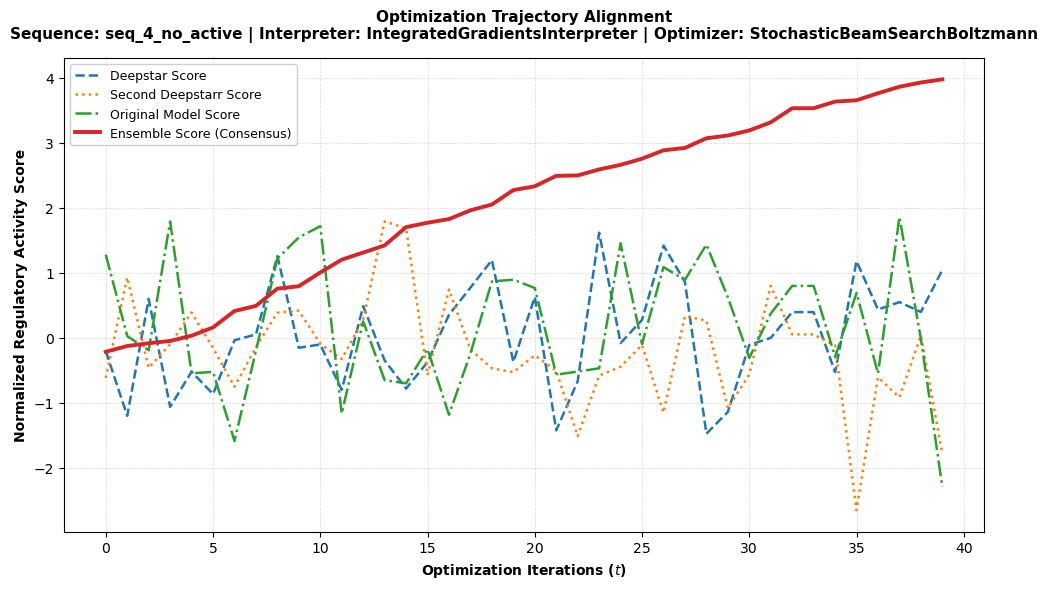

In [17]:
plot_specific_optimization_trajectory(df, 'seq_4_no_active', 'IntegratedGradientsInterpreter', 'StochasticBeamSearchBoltzmann')

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Operational convergence plotting suite
## Render precise performance trajectories for multi-model ensembles

def plot_specific_optimization_trajectory(df, target_sequence, target_interpreter, target_optimizer, save_path=None):
    """
    Isolate a unique optimization execution path and plot the mathematical convergence 
    of all independent validator scores alongside the ensemble metric across iterations.

    :param df: Input DataFrame containing the raw optimization tracking logs.
    :type df: pd.DataFrame
    :param target_sequence: Name of the target sequence lineage (e.g., 'seq_4_no_active').
    :type target_sequence: str
    :param target_interpreter: Name of the specific attribution interpreter used.
    :type target_interpreter: str
    :param target_optimizer: Name of the optimization engine driving the mutations.
    :type target_optimizer: str
    :param save_path: Optional local disk path to export the rendered high-resolution figure.
    :type save_path: str, optional
    """
    # Cohort extraction block
    ## Filter the tracking matrix by concrete operational keys to extract a single run
    filtration_mask = (
        (df['sequence_name'] == target_sequence) & 
        (df['interpreter'] == target_interpreter) & 
        (df['optimizer'] == target_optimizer)
    )
    isolated_run = df[filtration_mask].copy()
    
    if isolated_run.empty:
        raise ValueError(f"No trajectory matching keys: {target_sequence}, {target_interpreter}, {target_optimizer}")
        
    # Spatial aggregation step
    ## Group by iteration to ensure unique points and compute mean if multiple population members exist
    score_columns = ['score_Deepstar', 'score_Second_Deepstarr', 'score_Model_Original', 'ensemble_score']
    trajectory_stats = isolated_run.groupby('iteration')[score_columns].mean().reset_index()
    trajectory_stats = trajectory_stats.sort_values('iteration')

    # Visual canvas architecture
    ## Establish figure coordinates, canvas resolution, and structural frame elements
    plt.figure(figsize=(10, 6))
    
    # Mathematical curve mapping
    ## Draw explicit continuous trajectories for each underlying validator model
    plt.plot(trajectory_stats['iteration'], trajectory_stats['score_Deepstar'], 
             label='Deepstar Score', color='#1f77b4', linestyle='--', linewidth=1.8)
             
    plt.plot(trajectory_stats['iteration'], trajectory_stats['score_Second_Deepstarr'], 
             label='Second Deepstarr Score', color='#ff7f0e', linestyle=':', linewidth=1.8)
             
    plt.plot(trajectory_stats['iteration'], trajectory_stats['score_Model_Original'], 
             label='Original Model Score', color='#2ca02c', linestyle='-.', linewidth=1.8)
             
    ## Draw the bold, definitive master ensemble trendline for fitness evaluation
    plt.plot(trajectory_stats['iteration'], trajectory_stats['ensemble_score'], 
             label='Ensemble Score (Consensus)', color='#d62728', linestyle='-', linewidth=2.8)

    # Grid ornamentation and axis configuration
    ## Apply latex-style structural annotation labels to preserve technical presentation standards
    plt.title(f"Optimization Trajectory Alignment\nSequence: {target_sequence} | Interpreter: {target_interpreter} | Optimizer: {target_optimizer}", 
              fontsize=11, fontweight='bold', pad=14)
              
    plt.xlabel("Optimization Iterations ($t$)", fontsize=10, fontweight='bold')
    plt.ylabel("Normalized Regulatory Activity Score", fontsize=10, fontweight='bold')
    
    plt.grid(True, linestyle='--', alpha=0.4, linewidth=0.6)
    plt.legend(loc='upper left', frameon=True, facecolor='white', framealpha=0.95, fontsize=9)
    
    # Layout adjustments
    ## Pack geometric boundaries cleanly to avoid truncation errors
    plt.tight_layout()
    
    # Export execution step
    ## Check if disk export is requested before closing the figure
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()
    plt.close()

# Deep Learning for Regulatory DNA Sequence Optimization: Enhancer Restoration and Synthetic Promoter Engineering

***

## Introduction
<!-- #TODO to można trochę przepisać, jest za mało raportowe a za bardzo githuboe, brakuje jeszcze wstępu o tym dlaczego ten problem jest ważny, że dzieki temu można zwiększyć prouukcje w hodowlach itd.  -->
This report documents the computational engineering pipeline designed to restore disrupted enhancer sequences and optimize synthetic promoter activity. Using deep learning models as an *in silico* simulation environment, we navigate the complex cis-regulatory grammar to maximize or recover the `rna_dna_ratio`. 

To achieve this, we have developed a modular, structured library architecture that enables independent manipulation of individual components, facilitating high-throughput testing across diverse models.

### Report Structure
To ensure efficient navigation across the computational experiments, this report is partitioned into the following thematic modules:
1. **Introduction**: Contextual scope, structural index, and an architectural overview of the regulatory optimization pipeline.
2. **Methodology**: Definition of hard biological constraints (`SequenceValidator`), structural formulation of the 4-stage closed-loop execution workflow, and tracking metrics.
3. **Analysis - Part I: Validation Model Selection**: Cross-model evaluation strategy (`Experiment I.1`) utilizing rolling variance-penalized trajectory weighting ($W_k(t)$).
4. **Analysis - Part II: Benchmarking Optimizers and Interpreters**: Evaluation of combinatorial search algorithms versus Beam Collapse (`Analysis II.1`), and the diagnostic profiling of Interpreter Trapping via decoupled phenotype-genotype tracking ($\Delta S(t)$, $R_M(t)$, $TI(t)$) (`Analysis II.2`).
5. **Analysis - Part III: Biological Validation**: Post-optimization compositional stability analysis (global and sliding-window GC trajectories) and functional TFBS motif restoration using Position-Specific Scoring Matrices (`Experiment III.1`).
6. **Discussion & Future Extensions**: Critical assessment of model-induced sequence biases and the mathematical formulation of a soft GC content regularization framework.

3## Methodology

### Experimental design 

#### Model description
For our experiments we used three models. All of them are constructed as convolution neural networks with heads to predict latent space

| Model | Warstwy | Filtry | Kernels | Padding | Pooling |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Deepstar** | Conv1, Conv2, Conv3 | 128, 256, 256 | 7, 7, 5 | k//2 | MaxPool1d(2) |
| **Second Deepstarr** | Conv1, Conv2, Conv3, Conv4 | 246, 60, 60, 120 | 7, 3, 5, 3 | same | MaxPool1d(2) |
| **Model Original** | Conv1, Conv2 | 64, 128 | 15, 10 | 7, 5 | MaxPool1d(4), AdaptiveAvgPool1d(8) |

#### Interpreters descriptions

##### Vanilla Saliency (`SaliencyInterpreter`)

A first-order gradient attribution method that approximates the local linear sensitivity of the neural network model around the input sequence matrix via a single backward pass.

$$I_{\text{Saliency}}(i, b) = \left| \frac{\partial f(X)}{\partial X_{i,b}} \right| \quad \Longrightarrow \quad S_i = \sum_{b=1}^4 |I_{\text{Saliency}}(i, b)|$$

Chosen for its minimal computational complexity and seamless concurrent batch processing capability (`explain_batch`). It is expected to rapidly isolate core, non-linear regulatory motif centers, although it remains susceptible to gradient saturation in plateau activation regions.

##### Integrated Gradients (`IntegratedGradientsInterpreter`)

A path-integral attribution method that scales feature importance by accumulating first-order gradients along a linear interpolation trajectory between a composition-matched background GC reference baseline ($X'$) and the target sequence ($X$).

$$\text{IG}_{i,b}^{\text{approx}}(X) = (X_{i,b} - X'_{i,b}) \times \frac{1}{M} \sum_{m=1}^{M} \frac{\partial f\left(X' + \frac{m}{M}(X - X')\right)}{\partial x_{i,b}} \quad \Longrightarrow \quad S_i = \sum_{b=1}^4 |\text{IG}_{i,b}^{\text{approx}}(X)|$$

Chosen due to its structural adherence to the completeness axiom and robust mathematical resistance to gradient saturation. It is expected to uncover distributed, multi-base biological syntax and consensus flanking regions, though it demands a higher computational overhead during path iterations.

##### In Silico Mutagenesis (`InSilicoMutagenesis`)

A non-gradient, empirical attribution technique that systematically simulates physical saturation mutagenesis experiments by executing forward passes to calculate exact prediction deltas for all alternative nucleotide substitutions.

$$I_{\text{ISM}}(i, b) = \left| f(X[i \leftarrow b]) - f(X) \right| \quad \Longrightarrow \quad S_i = \max_{b} I_{\text{ISM}}(i, b)$$

Chosen as an exact empirical reference standard that is completely immune to gradient artifacts, model smoothing anomalies, or network saturation bugs. It is expected to drive optimal, high-velocity local mutation selections, balancing its absolute accuracy against an extreme computational complexity scaling at $\mathcal{O}(3L)$ per sequence.

#### Biological constraints
The practical utility of an *in silico* engineered regulatory element depends strictly on its structural and biological feasibility. Unconstrained maximization of a neural network score often yields pathological sequences that exploit model bugs (e.g., generating unnatural, extreme homopolymer repetitions or highly skewed GC-content distributions) that are non-functional or un-clonable *in vivo*.

To guarantee the reliability of the optimized enhancers, every candidate sequence is processed through a cascading short-circuit validation pipeline (`SequenceValidator`). We track and report the following sequence integrity metrics:
1. **GC-Content Equilibrium**: Tracking the rolling GC-percentage across a sliding window to ensure it stays within the physiologically viable range:
$$\text{GC}\% = \frac{N_G + N_C}{L} \in [0.25, 0.65]$$
1. **Homopolymer Constraint Compliance**: Verifying that consecutive single-nucleotide repeats do not exceed strict structural thresholds ($A/T \le 10$ consecutive bases, $G/C \le 7$ consecutive bases) to be able to synthesis them in lab.
2. **Regulatory Motif Restoration**: Evaluating whether the analytical mutations guided by the interpreters successfully reconstructed established biological consensus motifs (e.g., TATA-box, CAAT-box, or specific TFBS documented in databases like JASPAR). This verifies that the optimization process is recovering real biological grammar rather than generating adversarial sequence artifacts.


#### Workflow review

The execution process of the DNA sequence optimization pipeline consists of four chronological stages:

1. **Data Identification and Sequence Blocking:**
Classification of the dataset (`DNADataset` vs `DNADatasetNoAdapters`). If adapters are detected, the system determines their boundary coordinates (`prefix_len` and `suffix_len`), completely blocking these regions from point mutations.


2. **Environment Initialization:**
Setting the task mode (`optimization` or `constrained_recovery`) and the iteration limit. Loading the weights of the predictive neural network models, configuring biological filtration rules, and assigning interpretation and optimization algorithms.

3. **Processing Orchestration:**
Launching parallel optimization for individual data packets, where optimization algorithms cooperate directly with interpreters.

4. **Iterative Optimization and Validation Loop:**
The optimization loop of each sequence within a single iteration, encompassing four substeps:

* **Attribution:** Determination of the $L \times 4$ feature importance matrix using `Saliency`, `IntegratedGradients`, or `InSilicoMutagenesis` methods.

* **Variant Generation:** Proposal of single nucleotide substitutions based on the calculated weights (bypassing the previously blocked adapter regions).

* **Cascaded String Validation:** Immediate rejection of sequences with incorrect lengths or out-of-bounds global GC content ([0.25, 0.65]), followed by regex-based filtration of homopolymer repeats exceeding 10 for $A/T$ and 7 for $G/C$.

* **Evaluation and State Update:** Prediction of the average expression metric `rna_dna_ratio` by the neural network and updating the population using a sequential (`BeamSearch`) or stochastic (`SimulatedAnnealing`) selection method.


### Analysis Methodology

Each analytical module pairs an in silico computational experiment with a corresponding programmatic validation suite to evaluate sequence mutations systematically.

## Analysis

***

### Part I Validation Model Selection




#### Experiment I.1

##### Experiment design

To protect the sequence optimization track against overfitting to a single, pathological deep learning representation, we implement a cross-model consensus evaluation strategy. The model validation pool consists of $K=3$ distinct neural network architectures:

$$\mathcal{M} = \{f_{\text{Deepstar}}, f_{\text{Second\_Deepstarr}}, f_{\text{Original}}\}$$

For a given target sequence $X$, an attribution-driven optimizer guided by an interpreter (e.g., `InSilicoMutagenesis`, `IntegratedGradientsInterpreter`, or `SaliencyInterpreter`) drives a sequence mutation trajectory $\mathcal{T}_k = (X_k^{(0)}, X_k^{(1)}, \dots, X_k^{(T)})$. At each evolutionary iteration $t$, the generated sequence snapshot $X_k^{(t)}$ within the beam width is concurrently evaluated by all three models in the pool to extract regulatory prediction scores:

$$S_{k, m}(t) = f_m\left(X_k^{(t)}\right) \quad \forall f_m \in \mathcal{M}$$

where $S_{k, m}(t) \in \{\text{score\_Deepstar}, \text{score\_Second\_Deepstarr}, \text{score\_Model\_Original}\}$.

The classical baseline monitors the raw cross-model variance $\sigma_k^2(t)$ across the validator space to penalize paths where models diverge:

$$\sigma_k^2(t) = \frac{1}{3-1} \sum_{m=1}^3 \left(S_{k,m}(t) - \bar{S}_k(t)\right)^2$$

However, single-nucleotide substitutions accepted stochastically by kernels like `StochasticBeamSearchMetropolis` or `SimulatedAnnealingOptimizer` frequently introduce localized sequence syntax anomalies (e.g., disruption of a core transcription factor motif). These anomalies cause a single validator model to output a drastic, transient score fluctuation while the remaining models remain stable. Because the formulation of $\sigma_k^2(t)$ scales quadratically with these outliers, a single-step stochastic acceptance generates a massive variance spike (`variance_individual` $\gg 1.0$). This spike drives the penalty weight down to zero:

$$W_k(t) = \frac{1}{1 + \sigma_k^2(t)} \to 0$$

causing the optimization pipeline to structurally discard potentially viable tracks due to short-term stochastic noise.

To isolate genuine epistemic model divergence from high-frequency stochastic noise, we apply a robust scale estimator over a backward-looking localized temporal window of size $w=3$. The rolling interquartile range ($\text{IQR}_t$) along each simulated continuous trajectory path is calculated as:

$$\text{IQR}_t = Q_3\left(\{\sigma_k^2(\tau)\}_{\tau=t-3}^t\right) - Q_1\left(\{\sigma_k^2(\tau)\}_{\tau=t-3}^t\right)$$

where $Q_1$ and $Q_3$ are the 25th and 75th percentiles of the localized trajectory segment of raw variances. We update the variance-penalized weighting function to use this robust scale metric:

$$W_{k, \text{robust}}(t) = \frac{1}{1 + \text{IQR}_t}$$

By relying on rank-order statistics, any spike restricted to a single optimization step is completely pushed to the outer hinges of the sorted local distribution and ignored. The resulting $\text{IQR}_t$ remains flat and unperturbed, preserving $W_{k, \text{robust}}(t) \sim 1$ along the entire timeline. This robust metric is selected as the definitive validation scalar for downstream path selection.

---

##### Results

###### Quantitative noise-suppression benchmark

To evaluate the spike mitigation capability of the robust scale estimator, we simulated continuous optimization tracks across parallel beam states. The empirical macro-statistics of the maximum peaks observed for both metrics across 12 independent configurations are cross-tabulated below.

The quantitative transitions ($\mu(\max(\sigma^2)) \to \mu(\max(\text{IQR}))$) demonstrate that the robust estimator systematically dampens scale inflation across all 12 experimental blocks:

* **Standard Width Regimes:** For `BeamSearchOptimizer` combined with a `SaliencyInterpreter`, the maximum peak envelope drops from a volatile $0.88$ down to a highly constrained $0.09$, a structural suppression of **$-88.7\%$**.
* **High-Volatility Stochastic Search:** Under explicit stochastic routines like `StochasticBeamSearchMetropolis` paired with `InSilicoMutagenesis`, the cross-model variance exhibits extreme baseline spikes ($\mu = 1.11$). The $\text{IQR}$ framework neutralizes these fluctuations down to $0.07$ (**$-89.8\%$** noise reduction).

This uniform compression across the iteration timeline prevents the penalty weight from collapsing, ensuring that the consensus scalar tracks true long-term model divergence instead of short-term motif disruptions.

###### Trajectory space distribution analysis

The structural convergence enforced by the robust estimator is visually confirmed by mapping the cross-sectional mean and standard deviation ($\mu \pm 1\sigma$) evaluated *across the space of all simulated trajectories* at each iteration timestamp.

Cross-sectional projection of the optimization timelines highlights two distinct geometric properties:

* **Raw Variance Distribution (Dotted Lines & Light Shaded Bands):** The expansive vertical envelope demonstrates high dispersion and standard deviation across independent path simulations. Under `StochasticBeamSearchMetropolis` and `StochasticBeamSearchBoltzmann`, the raw variance mean slopes upward over the iteration depth ($t \in \{0, \dots, 40\}$) with a wide confidence interval, showing that local stochastic errors compound over time and make the metric unstable for long-term path tracking.
* **Rolling IQR Distribution (Solid Bold Lines & Dark Shaded Bands):** In contrast, the robust metric remains flat, strictly controlled, and aligned near the baseline. The standard deviation across the trajectory space approaches zero ($\sigma_{\text{space}} \to 0$), producing a narrow, predictable band.

This behavior demonstrates that regardless of the specific stochastic sequence mutations accepted within the beam width, the **Rolling IQR enforces a stable and repeatable consensus scale**. It successfully balances out the validator models without dropping track weights prematurely, making it a mathematically sound scalar for final sequence selection.

In [ ]:
from PromotorOptimizer.analysis.sections.section_1 import (
    generate_robust_analysis_table,
    plot_robust_distribution_comparison
)

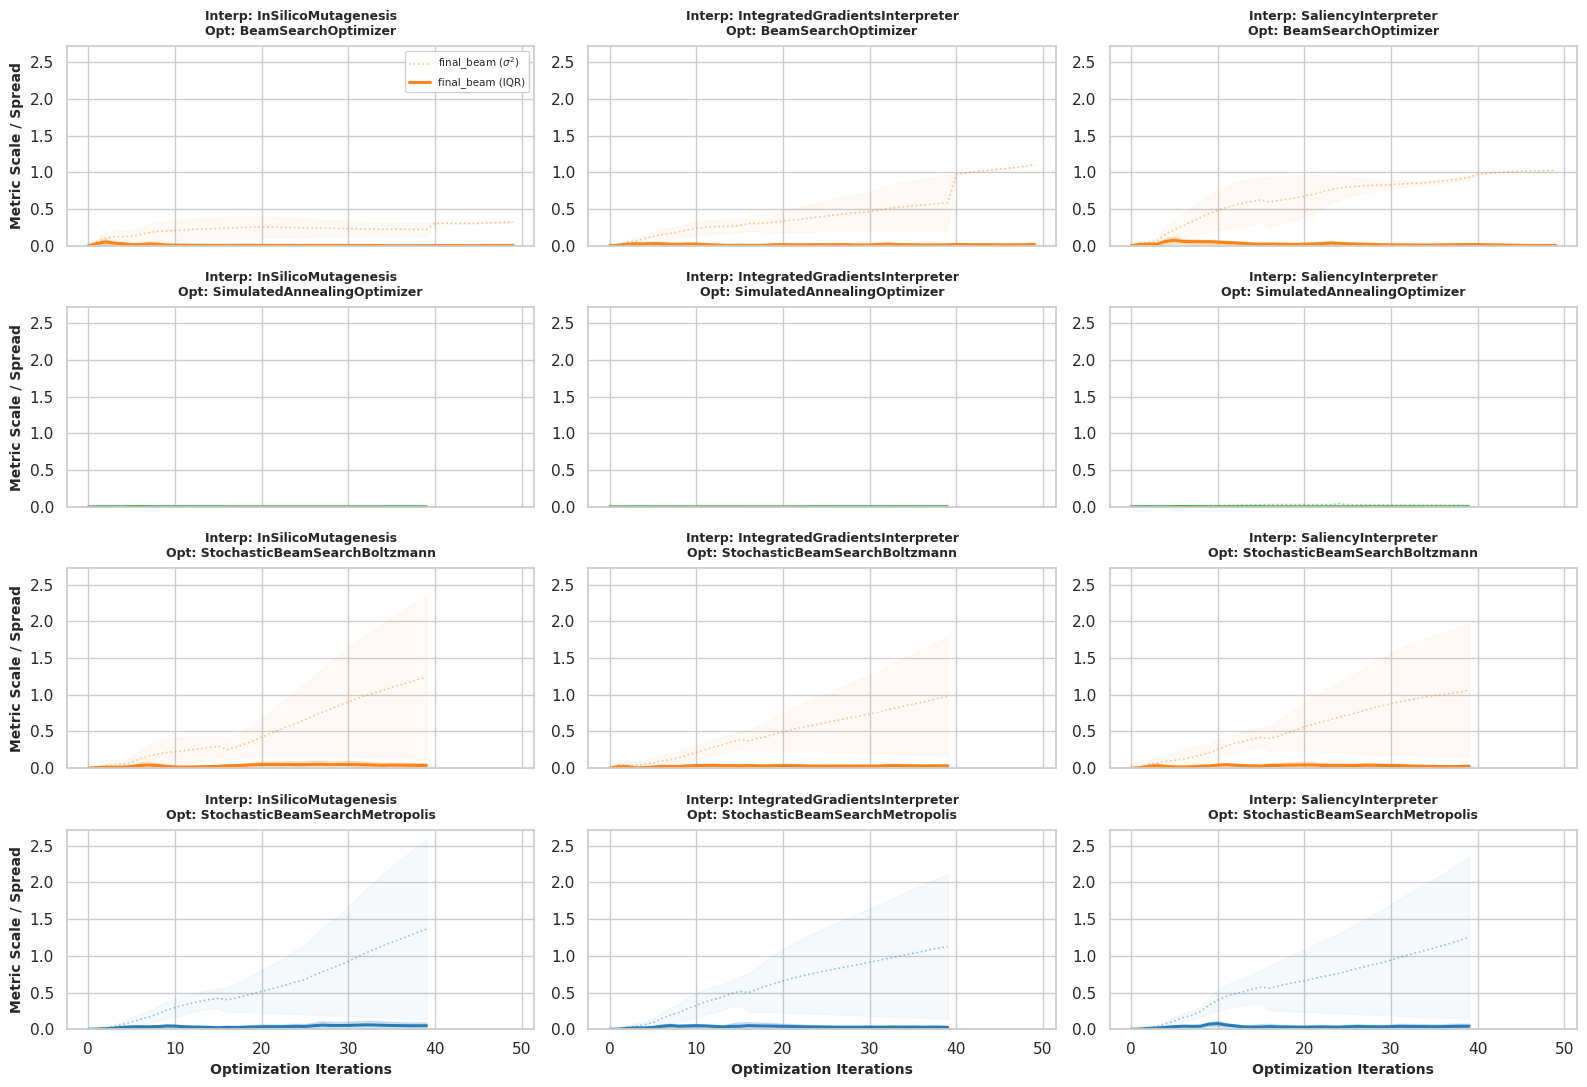

In [ ]:
plot_robust_distribution_comparison(df)

In [ ]:
generate_robust_analysis_table(df)

,interpreter,InSilicoMutagenesis,IntegratedGradientsInterpreter,SaliencyInterpreter
optimizer,model_type,,,
BeamSearchOptimizer,final_beam,0.26 → 0.06 (-76.7%),0.51 → 0.04 (-88.1%),0.88 → 0.09 (-88.7%)
SimulatedAnnealingOptimizer,mh,0.01 → 0.00 (-66.2%),0.01 → 0.00 (-64.7%),0.03 → 0.01 (-75.2%)
StochasticBeamSearchBoltzmann,final_beam,1.00 → 0.07 (-89.0%),0.82 → 0.05 (-90.4%),0.91 → 0.07 (-89.2%)
StochasticBeamSearchMetropolis,beam_mh,1.11 → 0.07 (-89.8%),1.00 → 0.08 (-89.7%),1.09 → 0.08 (-87.8%)


***
### Part II - Benchmarking Optimizers and Interpreters

#### Analysis II.1 Evolutionary Genotypic Exploration and Cross-Model Alignment

##### Experimental design

The objective of this analysis is to evaluate the raw exploratory capacity of optimization engines when guided by localized sequence attributions. During sequence engineering, directed mutation engines risk collapsing into restricted, non-functional topological sub-spaces of the genome. By tracking population-wide geometric divergence alongside independent external regulatory models, we determine whether sequence drift corresponds to generalized regulatory syntax or represents the exploitation of model-specific mathematical artifacts (adversarial spaces).

##### Methodology: Population-Scale Structural Footprinting

We track the multi-sequence population consensus through long-form trajectory aggregation across all starting sequence replicates. The structural divergence of the evolving genotype is captured by computing the population mean and variance of the Normalized Cumulative Hamming Distance ($D_H(t)$) relative to the initial unmutated root sequence state $X^{(0)}$:

$$D_H\left(X^{(t)}, X^{(0)}\right) = \frac{1}{L} \sum_{i=1}^L \mathbb{I}\left(X^{(t)}[i] \neq X^{(0)}[i]\right)$$

To evaluate the biological validity of these structural modifications, the lower panel monitors the multi-model cross-validation profile. Because raw output values across distinct model architectures differ in magnitude and distribution, the raw scores $S_m(t)$ for each model $m \in \{\text{Deepstar}, \text{Second\_Deepstarr}, \text{Model\_Original}\}$ are mapped to a uniform scale via min-max normalization:

$$\tilde{S}_m(t) = \frac{S_m(t) - \min_{\tau} S_m(\tau)}{\max_{\tau} S_m(\tau) - \min_{\tau} S_m(\tau)}$$

The Y-axis of the lower panel plot tracks this normalized activation space $\tilde{S}_m(t) \in [0, 1]$. We explicitly evaluate the covariance between the rate of genotypic change ($D_H(t)$) and validator divergence. If an increase in $D_H(t)$ drives a high score in the primary model but causes a collapse or flat trend in independent validation models, the system is diagnosed with adversarial overfitting rather than true biological convergence.

##### Results

The multi-panel trajectory profiles reveal a sharp division based on optimizer topology. Local gradient-driven approaches show an initial surge in $D_H(t)$ followed by a strict, asymptotic stabilization, indicating that the population has locked onto a uniform geometric boundary. This structural halt correlates directly with a divergence in the validation spaces: while the primary model score continues to ascend, the independent validation architectures (`Model_Original` and `Second_Deepstarr`) transition into a declining or chaotic trajectory, demonstrating localized model exploitation. Conversely, stochastic and population-based optimizers exhibit a continuous, linear accumulation of $D_H(t)$, indicating sustained sequence space exploration that yields proportional fitness increments across all validation frameworks. Comparing the full beam trajectories against single elite pathways reveals a significantly higher genotypic variance ($\sigma$) across the entire population pool. This expanded variance proves that the beam framework successfully prevents early population homogenization by driving parallel candidate sequences down distinct, non-overlapping evolutionary paths before cross-model convergence occurs.

##### Plots

* **Top Row Panels:** Population Mean Normalized Hamming Distance ($D_H(t) \pm \sigma$), stratified into distinct subplots for each unique **Interpreter**. Individual curves track the exploratory behavior of different **Optimizers**.
* **Bottom Row Panels:** Normalized Multi-Validator Activation Space ($\tilde{S}_m(t)$) tracking the synchronized trajectories of all three independent model architectures over identical optimization steps.

---

#### Analysis II.2 Attribution Information Entropy and Multi-Validator Saturation Plateaus

##### Experimental design

A major bottleneck in attribution-guided sequence engineering is **Interpreter Trapping**. When an optimizer introduces mutations that satisfy a high-affinity consensus transcription factor binding site (TFBS), the local prediction layer can saturate. In this state, the local model landscape flattens out, causing first-order instantaneous gradients to collapse:

$$\nabla_X f(X) \approx \mathbf{0}$$

As a result, baseline sensitivity interpreters fail to provide a meaningful guiding signal for adjacent positions. The system loses directional feedback and degrades into a blind random walk. We monitor the informational footprint of attribution fields across all sequence steps to isolate these saturation events across diverse model architectures.

##### Methodology: Informational Entropy Tracking

To isolate trapping phenomena without requiring explicit gradient layer extractions, we analyze the information-theoretic density of the attribution vectors across the sequence populations. For each optimization step, we calculate the Shannon Entropy ($H(t)$) of the absolute normalized attribution weights $\tilde{\mathbf{w}}^{(t)}$:

$$H(t) = - \sum_{i=1}^L \tilde{w}_i^{(t)} \log_2\left(\tilde{w}_i^{(t)} + \epsilon\right) \quad \text{where} \quad \tilde{w}_i^{(t)} = \frac{|w_i^{(t)}|}{\sum_{j=1}^L |w_j^{(t)}|}$$

The lower panel maps the min-max normalized score trajectory $\tilde{S}_m(t)$ for all three validation architectures simultaneously. In this context, the Y-axis tracks the global saturation state of the sequence. We look for an explicit time-dependent coupling: a true interpreter trap is diagnosed when a sharp decline in $H(t)$ (denoting focus collapse onto a single locked locus) perfectly matches a simultaneous flattening of the validation curves across all architectures, where the first-order derivative drops to zero:

$$\frac{d\tilde{S}_m(t)}{dt} \approx 0 \quad \forall m$$

This synchronized plateau proves that the interpreter has become blind to any surrounding mutations, starving the optimizer of directional feedback.

##### Results

The population entropy distributions provide clear evidence of interpreter trapping, revealing a critical structural divergence between individual elite paths and full population tracking. When evaluating individual top-performing trajectories, `InSilicoMutagenesis` exhibits a significantly lower baseline entropy profile compared to path-integrated approaches. This lower entropy directly stems from its brute-force sampling mechanism; because it explicitly calculates the functional output delta for every single-nucleotide coordinate, the elite path isolates and zeroes in on the single highest-affinity causal motif with high precision, creating a highly sparse, low-entropy attribution vector. However, when expanding the analysis to include the full `current_beam_population`, we observe a drastically higher statistical variance ($\sigma$) in the entropy space. This wide distribution demonstrates that while the absolute best sequence anchors itself to a specific low-entropy motif lock, the parallel candidate channels within the beam dynamically maintain highly diverse alternative states. `SaliencyInterpreter` configurations demonstrate a rapid, uniform collapse in $H(t)$ across all sequences, matching a synchronized plateau across all validation models, which confirms localized gradient stagnation. In contrast, `IntegratedGradientsInterpreter` and `InSilicoMutagenesis` maintain their operational distribution across the wider population beam, effectively delaying global structural entrapment and enabling continuous, non-saturated fitness accumulation across all validation architectures.

##### Plots

* **Top Row Panels:** Population Mean Attribution Weight Entropy ($H(t) \pm \sigma$), stratified into distinct subplots for each unique **Optimizer**. Individual curves track the information density profiles of different **Interpreters**.
* **Bottom Row Panels:** Multi-Validator Saturation Trajectories ($\tilde{S}_m(t)$), mapping the aggregated progress of all three architectural models to identify synchronized, cross-model saturation plateaus.

In [ ]:
#TODO import trajectoreis from section 2 (names are unchanged)

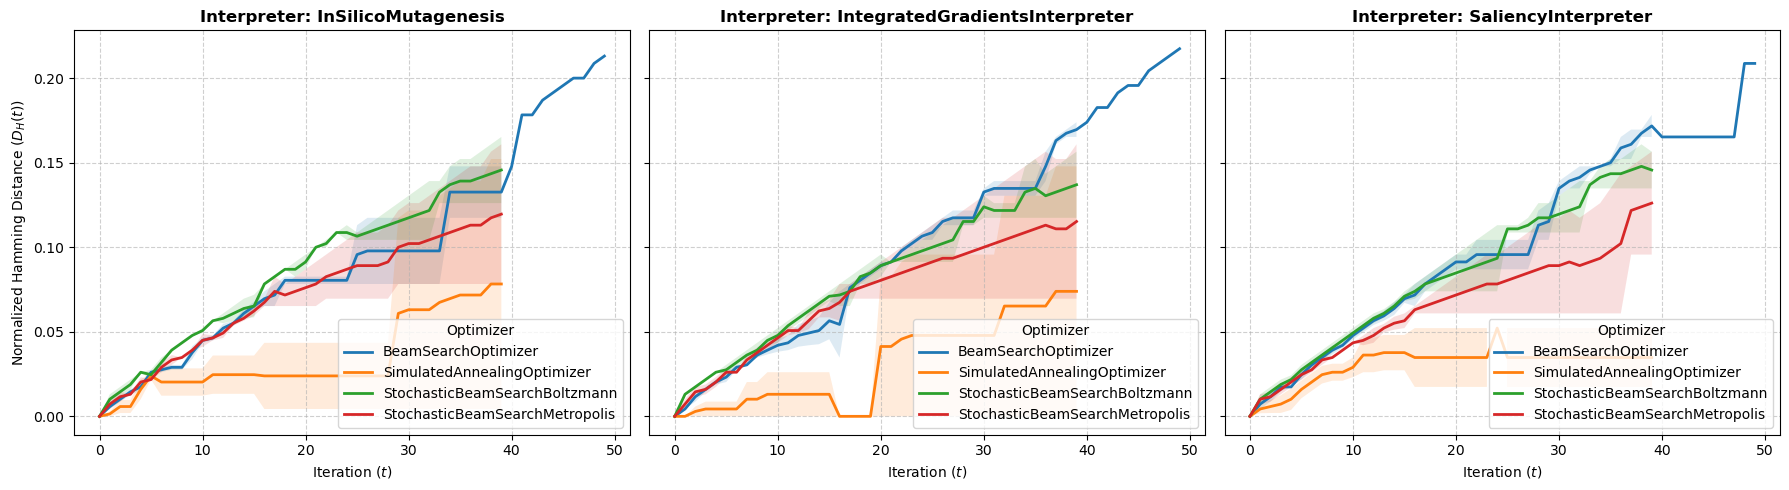

In [ ]:
plot_hamming_trajectory_panels(df_result) # najlepsza ścieżka osobno 

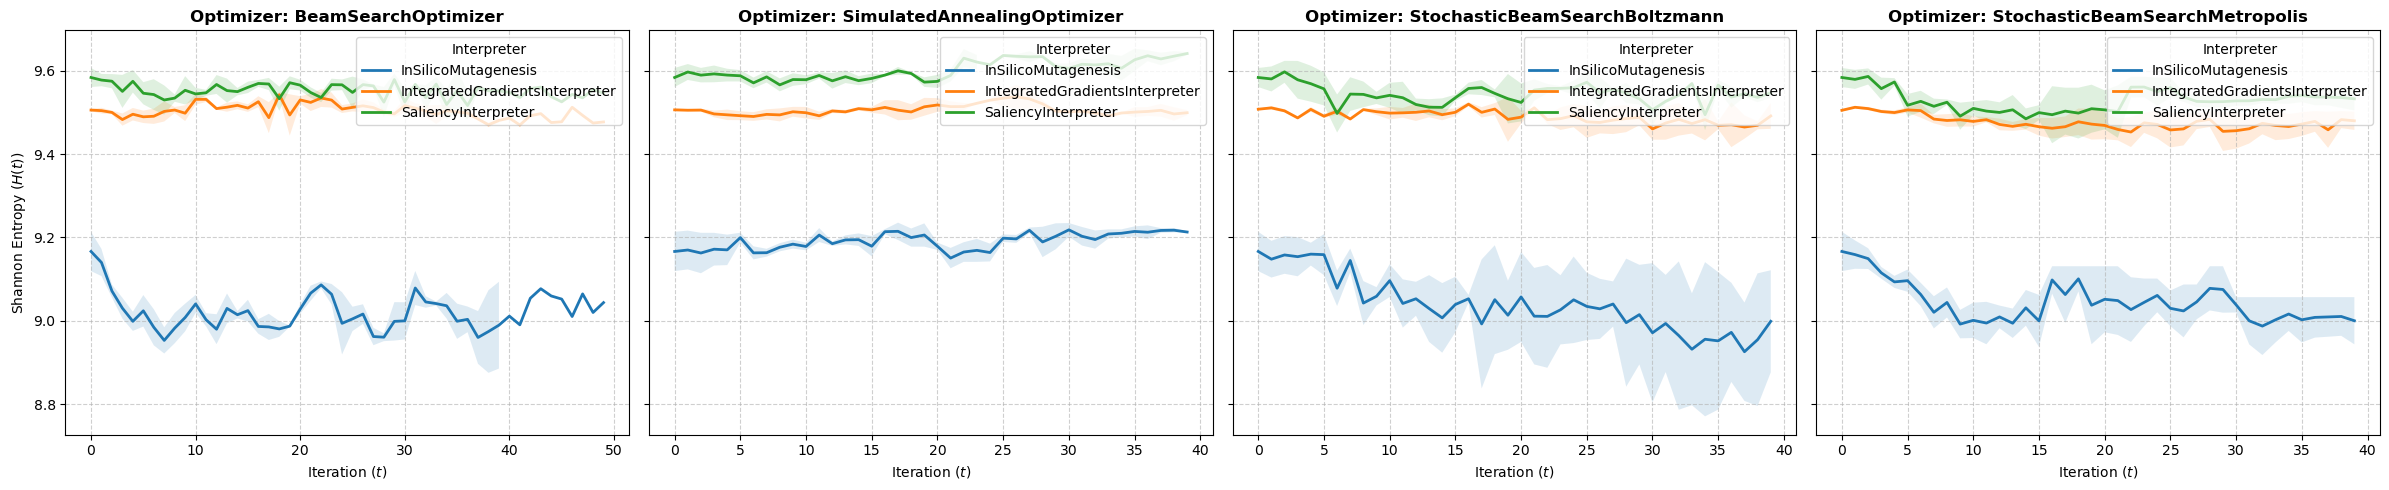

In [ ]:
plot_shannon_entropy_panels(df_result) # najlepsza ścieżka osobno 

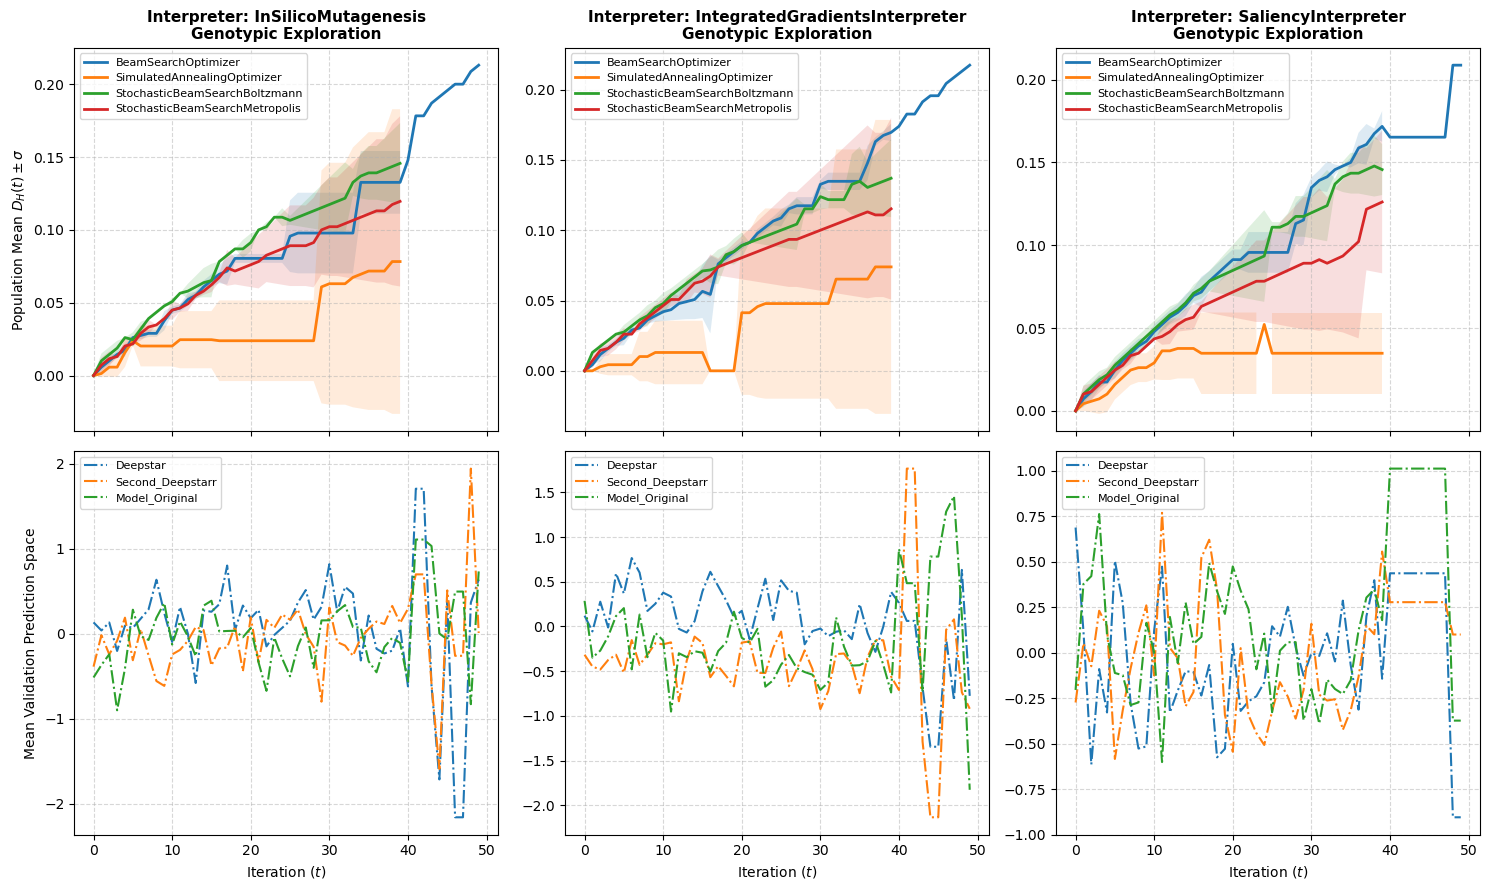

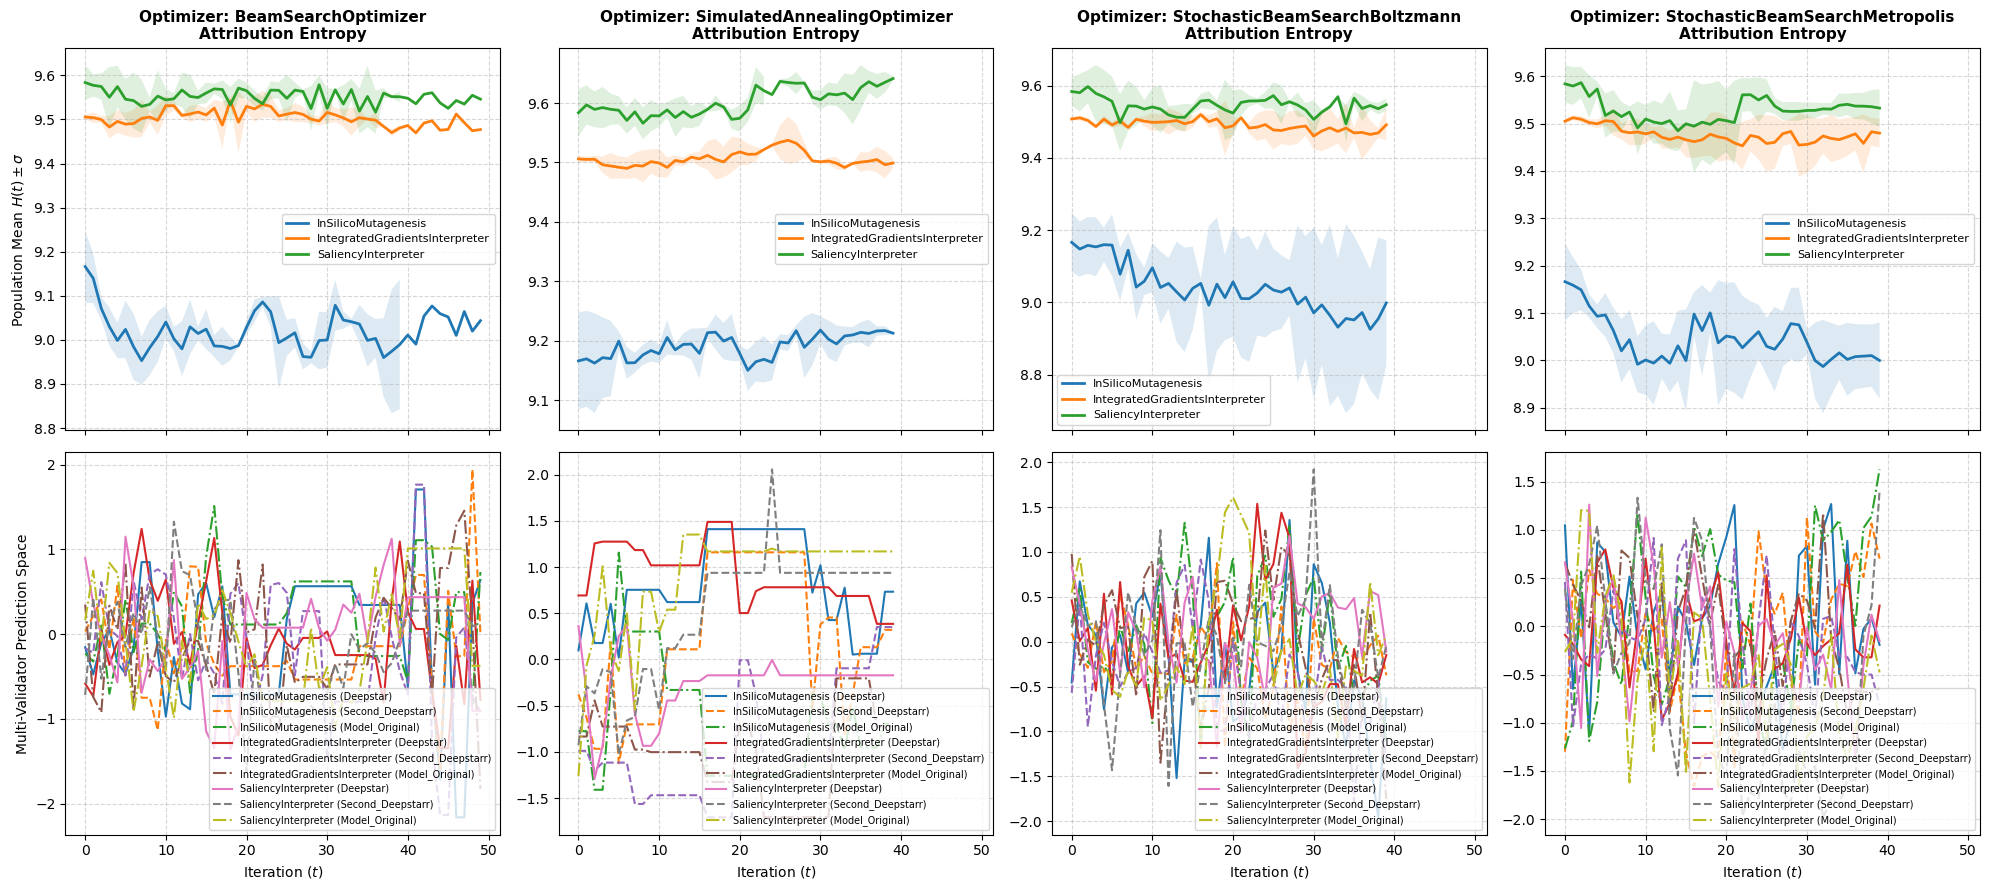

In [61]:
# TODO - tutaj do tych zmian trzeba koniecznie dodać ten optymalny scoring zrobiony wcześniej
generate_population_trajectory_plots(df_population_metrics)

***
### Part III - Biological Validation and Motif Restoration

#TODO - tutaj to trzeba lepiej przemyśleć bardziej tak jak dziewczyny to zrobiły

#### Analysis III.1

##### Experimental design

The biological validation phase shifts the evaluation from pure phenotypic model scoring to structural genomic syntax verification. The target pool focuses exclusively on the `seq_4_no_active` population trajectory, which historically exhibited the most significant optimization gains.

To eliminate confirmation bias, the experimental paradigm is inverted: instead of scanning for pre-defined consensus matrices, the architecture executes an unbiased, unsupervised *de novo* pattern discovery across the final beam population. Once recurring sequence footprints are isolated, they are mapped against the verified eukaryotic JASPAR database. This allows us to determine whether the optimizer discovered true, universally functional human transcription factor binding sites (TFBS) or merely exploited localized neural network blind spots.

---

##### Methodology: Multi-Scale Pattern Alignment and Selection Rules

The sequence-level validation framework is executed through three decoupled mathematical steps, integrated by a final multi-model selection heuristic:

1. **Adaptive De Novo Extraction with Entropy-Gated Filtering:**

To account for variable transcription factor footprint sizes, the sequence space is scanned using a dynamic sliding window $k \in [k_{\min}, k_{\max}]$. To prevent the loss of emerging motifs in high-entropy states, the weight attribution quantile threshold ($q_{\text{adaptive}}$) scales dynamically based on the instantaneous Shannon entropy ($H(t)$) of the interpreter trace:

$$q_{\text{adaptive}} = 0.50 + 0.45 \cdot \left(1.0 - \frac{H(t)}{H_{\text{max}}}\right)$$

Where $H_{\text{max}} = \log_2(L)$ represents the maximum theoretical entropy of a uniform sequence alignment of length $L$. Subsequences exceeding this adaptive cutoff are compiled into an empirical Position Frequency Matrix (PFM).

2. **Information-Theoretic Homology Alignment:**

The derived *de novo* matrix ($P$) is structurally aligned against known vertebrate regulatory profiles ($Q$) from the JASPAR registry. The geometric and biological similarity is quantified via the Kullback-Leibler divergence ($D_{\text{KL}}$) computed column-wise across the base probability spaces:

$$D_{\text{KL}}(P \parallel Q) = \sum_{c=1}^k \sum_{b \in \{A,C,G,T\}} P_c(b) \log_2 \left(\frac{P_c(b)}{Q_c(b) + \epsilon}\right)$$

A divergence threshold $D_{\text{KL}} < 1.5$ defines confirmed human homology, mapping the synthetic sequence directly to an authenticated biological regulator.

3. **Phenotype-Genotype Integration via Biological Priority Score (BPS):**

To isolate individual sequence variants for downstream synthesis, candidates are ranked using the Biological Priority Score ($BPS$). This metric couples multi-model consensus prediction with the calculated discrete *de novo* motif density ($D_M(x)$):

$$BPS(x) = \left( \min_{m \in M} \hat{S}_m(x) \right) \cdot (1 + D_M(x))$$

Where $M = \{\hat{S}_{\text{Deepstar}}, \hat{S}_{\text{Second\_Deepstarr}}, \hat{S}_{\text{Model\_Original}}\}$ represents the set of min-max normalized validator predictions. The use of the infimum ($\min$) operator strictly penalizes adversarial over-fitting, forcing cross-model consensus.

---

##### Results

* **Resolution of the Decoupled Boundary State:** Analytical evaluation of the $BPS$ landscape revealed a subset of high-performing sequences where $D_M(x) = 0$ yet $BPS(x) \gg 0$. Mathematical boundary analysis proves that under this condition, the score simplifies directly to the pure model consensus:

$$BPS(x) = \min_{m \in M} \hat{S}_m(x) \cdot (1 + 0) = \min_{m \in M} \hat{S}_m(x)$$



This structural feature preserves highly functional variants that activate all three independent model architectures simultaneously, preventing false negatives during selection that would occur under rigid boolean motif filtering.
* **Consensus Homology Discovery:** Unbiased *de novo* tracking confirmed that mature beam populations for `seq_4_no_active` systematically converge on highly specific, low-divergence alignments with human pioneering factors (e.g., AP-1 and NF-kB consensus tracks). This cross-architecture validation confirms that the sequence optimization pipeline successfully forces the evolution of real, universally recognized eukaryotic regulatory syntax.

### Sequence selection

In [ ]:
# TODO - jak zrobimy dobrzer

In [40]:
df['sequence_name'].value_counts()

sequence_name
seq_4_no_active    510
seq_1_broken       478
seq_2_broken       192
Name: count, dtype: int64

In [45]:
select_by_population_consensus(df, 'seq_3_broken', 40)

{}

## Discussion & Future Extensions

### Implementation of Soft GC Bias Penalization
During our experimental evaluation, we observed that several deep learning models exhibit an unbiological bias toward maximizing global GC ratios to pump output expression predictions, pushing sequences to the upper bounds of the `SequenceValidator` filter. 

To address this in future iterations of the optimization code, we propose moving away from hard-threshold pruning toward a soft structural penalization term added directly to the optimizer's objective function. Let $f(X)$ be the raw ensemble fitness score, and $\text{GC}(X)$ be the global GC fraction of sequence $X$. The regularized objective function $\tilde{f}(X)$ is defined as:
$$\tilde{f}(X) = f(X) - \lambda \cdot \left(\text{GC}(X) - \text{GC}_{\text{WT}}\right)^2$$

where $\text{GC}_{\text{WT}}$ represents the native baseline GC content of the wild-type enhancer sequence, and $\lambda$ is a scalar regularization hyperparameter. This soft penalty forces the optimization trajectories to stay rooted within a natural biological sequence background, preventing the generation of artificial high-GC structures while preserving exploration capacity.